# 3. Baseline model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

X = df.drop('status', axis=1)
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.3f}")

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.816
Precision: 0.807
Recall: 0.824
F1 Score: 0.815
ROC AUC: 0.893
Confusion Matrix:
 [[935 222]
 [199 930]]


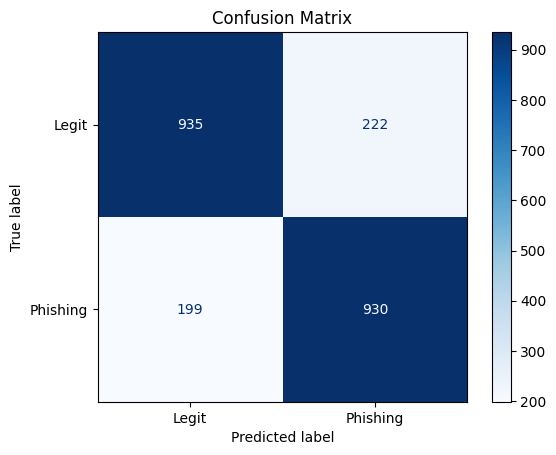

In [ ]:
# confusion matrix visual
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Interpretation:

- True Negatives (TN): 935 → Model correctly predicted class 0

- False Positives (FP): 222 → Model incorrectly predicted class 1 when it was actually 0
- False Negatives (FN): 199 → Model incorrectly predicted class 0 when it was actually 1
- True Positives (TP): 930 → Model correctly predicted class 1